# Germany and EU Tourism Competitiveness Analysis
## 03 - Exploratory Data Analysis

### Purpose

This notebook explores the cleaned tourism and economic datasets to identify patterns, trends, distributions, anomalies, and relationships relevant to Germany's tourism competitiveness.

The exploratory analysis focuses on:

- Germany's international tourism performance over time
- annual and monthly arrivals and overnight stays
- seasonality and monthly demand patterns
- Germany's position within the EU27
- differences between EU tourism markets
- international source-market structure
- source-market growth and demand concentration
- travel receipts, expenditure, and balance
- potential relationships requiring formal statistical testing
- anomalies, incomplete observations, and contradictory patterns

Exploratory findings will guide the formal statistical analysis conducted in the next notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
project_root = Path.cwd().parent

clean_path = project_root / "data" / "clean"
processed_path = project_root / "data" / "processed"
figures_path = project_root / "figures"

processed_path.mkdir(
    parents=True,
    exist_ok=True
)

figures_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", project_root)
print("Clean data:", clean_path)
print("Processed data:", processed_path)
print("Figures:", figures_path)

Project root: /Users/jannoelvero/Documents/germany_eu_tourism_analysis
Clean data: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/data/clean
Processed data: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/data/processed
Figures: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/figures


In [3]:
germany_nights = pd.read_csv(
    clean_path /
    "germany_foreign_nights_monthly_clean.csv",
    parse_dates=["date"]
)

eu27_nights = pd.read_csv(
    clean_path /
    "eu27_foreign_nights_monthly_clean.csv",
    parse_dates=["date"]
)

germany_arrivals = pd.read_csv(
    clean_path /
    "germany_foreign_arrivals_monthly_clean.csv",
    parse_dates=["date"]
)

eu27_arrivals = pd.read_csv(
    clean_path /
    "eu27_foreign_arrivals_monthly_clean.csv",
    parse_dates=["date"]
)

source_nights = pd.read_csv(
    clean_path /
    "germany_source_market_nights_annual_clean.csv"
)

source_arrivals = pd.read_csv(
    clean_path /
    "germany_source_market_arrivals_annual_clean.csv"
)

travel_bop = pd.read_csv(
    clean_path /
    "germany_travel_bop_annual_clean.csv"
)

source_market_reference = pd.read_csv(
    clean_path /
    "source_market_reference_clean.csv"
)

eu27_reference = pd.read_csv(
    clean_path /
    "eu27_country_reference_clean.csv"
)

print("All cleaned datasets loaded successfully.")

All cleaned datasets loaded successfully.


In [4]:
eda_structure = pd.DataFrame({
    "dataset": [
        "Germany Nights",
        "EU27 Nights",
        "Germany Arrivals",
        "EU27 Arrivals",
        "Source Market Nights",
        "Source Market Arrivals",
        "Travel BoP"
    ],
    "rows": [
        len(germany_nights),
        len(eu27_nights),
        len(germany_arrivals),
        len(eu27_arrivals),
        len(source_nights),
        len(source_arrivals),
        len(travel_bop)
    ]
})

eda_structure

,dataset,rows
0,Germany Nights,67
1,EU27 Nights,1809
2,Germany Arrivals,67
3,EU27 Arrivals,1809
4,Source Market Nights,315
5,Source Market Arrivals,315
6,Travel BoP,30


## Germany Tourism Performance

The analysis begins with Germany's international tourism performance.

Monthly foreign arrivals and overnight stays are aggregated into annual totals for complete historical years only. The 2026 observations are excluded from the annual historical series because the current data cover January through June only.

The analysis examines:

- annual international arrivals
- annual international overnight stays
- year-over-year growth
- average length of stay

Average length of stay is calculated as:

**Average Length of Stay = Foreign Overnight Stays / Foreign Arrivals**

In [5]:
germany_nights_annual = (
    germany_nights[
        germany_nights[
            "complete_12_month_year"
        ]
    ]
    .groupby("year")
    .agg(
        foreign_nights=(
            "foreign_nights",
            "sum"
        )
    )
    .reset_index()
)

germany_arrivals_annual = (
    germany_arrivals[
        germany_arrivals[
            "complete_12_month_year"
        ]
    ]
    .groupby("year")
    .agg(
        foreign_arrivals=(
            "foreign_arrivals",
            "sum"
        )
    )
    .reset_index()
)

germany_annual = (
    germany_arrivals_annual
    .merge(
        germany_nights_annual,
        on="year",
        how="inner",
        validate="one_to_one"
    )
)

germany_annual

,year,foreign_arrivals,foreign_nights
0,2021,11657007.0,30731500.0
1,2022,28382919.0,67616302.0
2,2023,34711761.0,80378429.0
3,2024,37419799.0,84792636.0
4,2025,37134349.0,83075445.0


In [6]:
germany_annual[
    "arrivals_yoy_pct"
] = (
    germany_annual[
        "foreign_arrivals"
    ]
    .pct_change()
    * 100
)

germany_annual[
    "nights_yoy_pct"
] = (
    germany_annual[
        "foreign_nights"
    ]
    .pct_change()
    * 100
)

germany_annual[
    "avg_length_of_stay"
] = (
    germany_annual[
        "foreign_nights"
    ]
    /
    germany_annual[
        "foreign_arrivals"
    ]
)

germany_annual

,year,foreign_arrivals,foreign_nights,arrivals_yoy_pct,nights_yoy_pct,avg_length_of_stay
0,2021,11657007.0,30731500.0,NaN,NaN,2.636311
1,2022,28382919.0,67616302.0,143.483760,120.022784,2.382289
2,2023,34711761.0,80378429.0,22.298066,18.874334,2.315596
3,2024,37419799.0,84792636.0,7.801500,5.491781,2.265983
4,2025,37134349.0,83075445.0,-0.762831,-2.025165,2.237159


In [7]:
germany_annual_summary = (
    germany_annual.copy()
)

germany_annual_summary[
    "foreign_arrivals"
] = (
    germany_annual_summary[
        "foreign_arrivals"
    ]
    .round(0)
    .astype(int)
)

germany_annual_summary[
    "foreign_nights"
] = (
    germany_annual_summary[
        "foreign_nights"
    ]
    .round(0)
    .astype(int)
)

germany_annual_summary[
    [
        "arrivals_yoy_pct",
        "nights_yoy_pct",
        "avg_length_of_stay"
    ]
] = (
    germany_annual_summary[
        [
            "arrivals_yoy_pct",
            "nights_yoy_pct",
            "avg_length_of_stay"
        ]
    ]
    .round(2)
)

germany_annual_summary

,year,foreign_arrivals,foreign_nights,arrivals_yoy_pct,nights_yoy_pct,avg_length_of_stay
0,2021,11657007,30731500,NaN,NaN,2.64
1,2022,28382919,67616302,143.48,120.02,2.38
2,2023,34711761,80378429,22.30,18.87,2.32
3,2024,37419799,84792636,7.80,5.49,2.27
4,2025,37134349,83075445,-0.76,-2.03,2.24


In [8]:
arrivals_change_pct = (
    (
        germany_annual.loc[
            germany_annual["year"] == 2025,
            "foreign_arrivals"
        ].iloc[0]
        /
        germany_annual.loc[
            germany_annual["year"] == 2021,
            "foreign_arrivals"
        ].iloc[0]
    )
    - 1
) * 100

nights_change_pct = (
    (
        germany_annual.loc[
            germany_annual["year"] == 2025,
            "foreign_nights"
        ].iloc[0]
        /
        germany_annual.loc[
            germany_annual["year"] == 2021,
            "foreign_nights"
        ].iloc[0]
    )
    - 1
) * 100

print(
    f"International arrivals change "
    f"2021-2025: {arrivals_change_pct:.2f}%"
)

print(
    f"International nights change "
    f"2021-2025: {nights_change_pct:.2f}%"
)

International arrivals change 2021-2025: 218.56%
International nights change 2021-2025: 170.33%


### Initial Findings

Germany experienced a strong recovery in international tourism between 2021 and 2024, followed by a modest decline in 2025.

International arrivals increased from approximately 11.7 million in 2021 to 37.4 million in 2024 before declining by 0.76% in 2025. International overnight stays followed a similar pattern, reaching approximately 84.8 million in 2024 before declining by 2.03% in 2025.

The recovery rate progressively slowed after 2022. Arrivals grew by 143.48% in 2022, 22.30% in 2023, and 7.80% in 2024 before contracting in 2025. Overnight-stay growth followed the same decelerating pattern.

A second important pattern is the decline in average length of stay, from 2.64 nights in 2021 to 2.24 nights in 2025. Arrivals generally recovered faster than overnight stays, indicating that Germany attracted substantially more international visitors while the average duration of their stays became shorter.

The total growth between 2021 and 2025 should be interpreted cautiously because 2021 represents an unusually low tourism base. The observed increase primarily reflects post-pandemic tourism recovery rather than a normal long-term growth rate.

In [9]:
stay_change_pct = (
    (
        germany_annual.loc[
            germany_annual["year"] == 2025,
            "avg_length_of_stay"
        ].iloc[0]
        /
        germany_annual.loc[
            germany_annual["year"] == 2021,
            "avg_length_of_stay"
        ].iloc[0]
    )
    - 1
) * 100

print(
    f"Average length of stay change "
    f"2021-2025: {stay_change_pct:.2f}%"
)

Average length of stay change 2021-2025: -15.14%


In [10]:
germany_annual[
    "growth_gap_pct_points"
] = (
    germany_annual[
        "arrivals_yoy_pct"
    ]
    -
    germany_annual[
        "nights_yoy_pct"
    ]
)

germany_annual[
    [
        "year",
        "arrivals_yoy_pct",
        "nights_yoy_pct",
        "growth_gap_pct_points"
    ]
].round(2)

,year,arrivals_yoy_pct,nights_yoy_pct,growth_gap_pct_points
0,2021,NaN,NaN,NaN
1,2022,143.48,120.02,23.46
2,2023,22.30,18.87,3.42
3,2024,7.80,5.49,2.31
4,2025,-0.76,-2.03,1.26


## Monthly Seasonality

Annual totals can conceal substantial variation in tourism demand throughout the year.

Monthly foreign arrivals and overnight stays are examined to identify Germany's seasonal tourism pattern.

The initial seasonality profile uses 2022–2025. The year 2021 is excluded from the structural seasonal average because tourism activity during that period was unusually affected by pandemic-related disruption.

The analysis evaluates:

- average demand by calendar month
- peak and low-demand months
- differences between arrival and overnight-stay seasonality
- average length of stay by month

In [11]:
seasonality_nights = (
    germany_nights[
        germany_nights["year"].between(
            2022,
            2025
        )
    ]
    .groupby("month")
    .agg(
        avg_foreign_nights=(
            "foreign_nights",
            "mean"
        )
    )
    .reset_index()
)

seasonality_arrivals = (
    germany_arrivals[
        germany_arrivals["year"].between(
            2022,
            2025
        )
    ]
    .groupby("month")
    .agg(
        avg_foreign_arrivals=(
            "foreign_arrivals",
            "mean"
        )
    )
    .reset_index()
)

germany_seasonality = (
    seasonality_arrivals
    .merge(
        seasonality_nights,
        on="month",
        validate="one_to_one"
    )
)

germany_seasonality[
    "avg_length_of_stay"
] = (
    germany_seasonality[
        "avg_foreign_nights"
    ]
    /
    germany_seasonality[
        "avg_foreign_arrivals"
    ]
)

germany_seasonality.round(2)

,month,avg_foreign_arrivals,avg_foreign_nights,avg_length_of_stay
0,1,1514757.25,3609018.25,2.38
1,2,1834711.50,4323426.00,2.36
2,3,2022277.25,4770581.75,2.36
3,4,2598305.00,6021141.75,2.32
4,5,3048231.75,7027344.75,2.31
5,6,3366929.00,7549799.75,2.24
6,7,4497764.00,10101711.50,2.25
7,8,4062102.50,9540407.00,2.35
8,9,3330940.25,7559254.00,2.27
9,10,2980900.75,6946164.25,2.33


In [12]:
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

germany_seasonality[
    "month_name"
] = (
    germany_seasonality[
        "month"
    ]
    .map(month_names)
)

germany_seasonality[
    [
        "month",
        "month_name",
        "avg_foreign_arrivals",
        "avg_foreign_nights",
        "avg_length_of_stay"
    ]
].round(2)

,month,month_name,avg_foreign_arrivals,avg_foreign_nights,avg_length_of_stay
0,1,January,1514757.25,3609018.25,2.38
1,2,February,1834711.50,4323426.00,2.36
2,3,March,2022277.25,4770581.75,2.36
3,4,April,2598305.00,6021141.75,2.32
4,5,May,3048231.75,7027344.75,2.31
5,6,June,3366929.00,7549799.75,2.24
6,7,July,4497764.00,10101711.50,2.25
7,8,August,4062102.50,9540407.00,2.35
8,9,September,3330940.25,7559254.00,2.27
9,10,October,2980900.75,6946164.25,2.33


In [13]:
peak_arrivals = germany_seasonality.loc[
    germany_seasonality[
        "avg_foreign_arrivals"
    ].idxmax()
]

low_arrivals = germany_seasonality.loc[
    germany_seasonality[
        "avg_foreign_arrivals"
    ].idxmin()
]

peak_nights = germany_seasonality.loc[
    germany_seasonality[
        "avg_foreign_nights"
    ].idxmax()
]

low_nights = germany_seasonality.loc[
    germany_seasonality[
        "avg_foreign_nights"
    ].idxmin()
]

print(
    "Peak arrivals month:",
    peak_arrivals["month_name"]
)

print(
    "Lowest arrivals month:",
    low_arrivals["month_name"]
)

print(
    "Peak nights month:",
    peak_nights["month_name"]
)

print(
    "Lowest nights month:",
    low_nights["month_name"]
)

Peak arrivals month: July
Lowest arrivals month: January
Peak nights month: July
Lowest nights month: January


### Seasonality Findings

Germany's international tourism demand shows a clear seasonal pattern.

Average foreign arrivals and overnight stays are lowest in January and increase steadily toward the summer period, reaching their highest levels in July. Average monthly arrivals rise from approximately 1.5 million in January to 4.5 million in July, while average monthly overnight stays increase from approximately 3.6 million to 10.1 million.

The peak in visitor volume does not correspond to the longest average stay. Average length of stay varies between approximately 2.20 and 2.38 nights across the year. January records the highest average stay duration, while December records the lowest.

This suggests that Germany's seasonal tourism performance is driven primarily by changes in visitor volume rather than large changes in trip duration.

The annual results support this interpretation. From 2022 onward, arrivals consistently grew faster than overnight stays. Together with the 15.14% decline in average length of stay between 2021 and 2025, this indicates that Germany's international tourism recovery has increasingly been driven by more visitors taking comparatively shorter stays.

In [14]:
monthly_stay = (
    germany_arrivals[
        germany_arrivals[
            "year"
        ].between(
            2022,
            2025
        )
    ][
        [
            "year",
            "month",
            "foreign_arrivals"
        ]
    ]
    .merge(
        germany_nights[
            germany_nights[
                "year"
            ].between(
                2022,
                2025
            )
        ][
            [
                "year",
                "month",
                "foreign_nights"
            ]
        ],
        on=[
            "year",
            "month"
        ],
        how="inner",
        validate="one_to_one"
    )
)

monthly_stay[
    "avg_length_of_stay"
] = (
    monthly_stay[
        "foreign_nights"
    ]
    /
    monthly_stay[
        "foreign_arrivals"
    ]
)

monthly_stay.head()

,year,month,foreign_arrivals,foreign_nights,avg_length_of_stay
0,2022,1,701139.0,1912992.0,2.728406
1,2022,2,1007194.0,2542987.0,2.524823
2,2022,3,1282377.0,3296966.0,2.570980
3,2022,4,2007686.0,4886184.0,2.433739
4,2022,5,2515321.0,6027813.0,2.396439


In [15]:
monthly_stay_pivot = (
    monthly_stay
    .pivot(
        index="month",
        columns="year",
        values="avg_length_of_stay"
    )
)

monthly_stay_pivot.round(2)

year,2022,2023,2024,2025
month,,,,
1,2.73,2.39,2.36,2.27
2,2.52,2.40,2.33,2.27
3,2.57,2.39,2.30,2.27
4,2.43,2.33,2.28,2.26
5,2.40,2.31,2.28,2.25
6,2.33,2.27,2.21,2.18
7,2.29,2.27,2.22,2.22
8,2.42,2.39,2.31,2.29
9,2.33,2.27,2.26,2.22


In [16]:
monthly_stay_change = (
    monthly_stay_pivot[
        2025
    ]
    -
    monthly_stay_pivot[
        2022
    ]
)

monthly_stay_change = (
    monthly_stay_change
    .reset_index(
        name="stay_change_nights"
    )
)

monthly_stay_change[
    "month_name"
] = (
    monthly_stay_change[
        "month"
    ]
    .map(
        month_names
    )
)

monthly_stay_change[
    [
        "month",
        "month_name",
        "stay_change_nights"
    ]
].round(2)

,month,month_name,stay_change_nights
0,1,January,-0.46
1,2,February,-0.26
2,3,March,-0.30
3,4,April,-0.17
4,5,May,-0.15
5,6,June,-0.14
6,7,July,-0.07
7,8,August,-0.13
8,9,September,-0.10
9,10,October,-0.15


In [17]:
print(
    "Months with shorter average stay:",
    (
        monthly_stay_change[
            "stay_change_nights"
        ] < 0
    ).sum()
)

print(
    "Months with longer average stay:",
    (
        monthly_stay_change[
            "stay_change_nights"
        ] > 0
    ).sum()
)

Months with shorter average stay: 12
Months with longer average stay: 0


### Monthly Stay-Duration Findings

The decline in Germany's average international length of stay is broad-based across the year.

Every calendar month recorded a shorter average stay in 2025 than in 2022. The largest reductions occurred in January, March, and February, while the declines were smaller during the summer peak period.

This indicates that the reduction in average stay duration is not driven by a single season or isolated monthly anomaly. Instead, it appears to reflect a consistent change in the structure of international tourism demand.

The pattern strengthens the earlier annual finding that Germany's tourism recovery has increasingly depended on visitor volume rather than longer stays.

In [18]:
eu27_nights_annual = (
    eu27_nights[
        eu27_nights[
            "complete_12_month_year"
        ]
    ]
    .groupby(
        [
            "country_code",
            "country",
            "year"
        ]
    )
    .agg(
        foreign_nights=(
            "foreign_nights",
            "sum"
        )
    )
    .reset_index()
)

eu27_nights_annual.head()

,country_code,country,year,foreign_nights
0,AT,Austria,2021,40034274.0
1,AT,Austria,2022,79470210.0
2,AT,Austria,2023,91023501.0
3,AT,Austria,2024,94009113.0
4,AT,Austria,2025,97020394.0


In [19]:
eu27_arrivals_annual = (
    eu27_arrivals[
        eu27_arrivals[
            "complete_12_month_year"
        ]
    ]
    .groupby(
        [
            "country_code",
            "country",
            "year"
        ]
    )
    .agg(
        foreign_arrivals=(
            "foreign_arrivals",
            "sum"
        )
    )
    .reset_index()
)

eu27_arrivals_annual.head()

,country_code,country,year,foreign_arrivals
0,AT,Austria,2021,11098084.0
1,AT,Austria,2022,22874333.0
2,AT,Austria,2023,27212813.0
3,AT,Austria,2024,28498633.0
4,AT,Austria,2025,29764173.0


In [20]:
nights_country_count = (
    eu27_nights_annual
    .groupby("year")
    .agg(
        countries_available=(
            "country_code",
            "nunique"
        )
    )
    .reset_index()
)

arrivals_country_count = (
    eu27_arrivals_annual
    .groupby("year")
    .agg(
        countries_available=(
            "country_code",
            "nunique"
        )
    )
    .reset_index()
)

print("Nights:")
display(nights_country_count)

print("Arrivals:")
display(arrivals_country_count)

Nights:


,year,countries_available
0,2021,25
1,2022,25
2,2023,25
3,2024,27
4,2025,27


Arrivals:


,year,countries_available
0,2021,22
1,2022,24
2,2023,24
3,2024,27
4,2025,26


In [21]:
eu27_nights_annual[
    "nights_rank"
] = (
    eu27_nights_annual
    .groupby("year")[
        "foreign_nights"
    ]
    .rank(
        method="min",
        ascending=False
    )
)

germany_nights_rank = (
    eu27_nights_annual[
        eu27_nights_annual[
            "country_code"
        ] == "DE"
    ][
        [
            "year",
            "foreign_nights",
            "nights_rank"
        ]
    ]
    .sort_values("year")
)

germany_nights_rank

,year,foreign_nights,nights_rank
22,2021,30731500.0,7.0
23,2022,67616302.0,7.0
24,2023,80378429.0,7.0
25,2024,84792636.0,7.0
26,2025,83075445.0,7.0


In [22]:
eu27_arrivals_annual[
    "arrivals_rank"
] = (
    eu27_arrivals_annual
    .groupby("year")[
        "foreign_arrivals"
    ]
    .rank(
        method="min",
        ascending=False
    )
)

germany_arrivals_rank = (
    eu27_arrivals_annual[
        eu27_arrivals_annual[
            "country_code"
        ] == "DE"
    ][
        [
            "year",
            "foreign_arrivals",
            "arrivals_rank"
        ]
    ]
    .sort_values("year")
)

germany_arrivals_rank

,year,foreign_arrivals,arrivals_rank
20,2021,11657007.0,4.0
21,2022,28382919.0,4.0
22,2023,34711761.0,4.0
23,2024,37419799.0,4.0
24,2025,37134349.0,4.0


In [23]:
eu27_nights_2025 = (
    eu27_nights_annual[
        eu27_nights_annual[
            "year"
        ] == 2025
    ]
    .sort_values(
        "foreign_nights",
        ascending=False
    )
    .reset_index(drop=True)
)

eu27_nights_2025[
    [
        "country_code",
        "country",
        "foreign_nights",
        "nights_rank"
    ]
].head(10)

,country_code,country,foreign_nights,nights_rank
0,ES,Spain,328928185.0,1.0
1,IT,Italy,301619611.0,2.0
2,FR,France,150753829.0,3.0
3,EL,Greece,131051335.0,4.0
4,AT,Austria,97020394.0,5.0
5,HR,Croatia,85604505.0,6.0
6,DE,Germany,83075445.0,7.0
7,NL,Netherlands,63849881.0,8.0
8,PT,Portugal,60022455.0,9.0
9,CZ,Czechia,26740457.0,10.0


In [24]:
eu27_arrivals_2025 = (
    eu27_arrivals_annual[
        eu27_arrivals_annual[
            "year"
        ] == 2025
    ]
    .sort_values(
        "foreign_arrivals",
        ascending=False
    )
    .reset_index(drop=True)
)

eu27_arrivals_2025[
    [
        "country_code",
        "country",
        "foreign_arrivals",
        "arrivals_rank"
    ]
].head(10)

,country_code,country,foreign_arrivals,arrivals_rank
0,IT,Italy,87897260.0,1.0
1,ES,Spain,79995359.0,2.0
2,FR,France,58749286.0,3.0
3,DE,Germany,37134349.0,4.0
4,AT,Austria,29764173.0,5.0
5,EL,Greece,28175239.0,6.0
6,NL,Netherlands,21855842.0,7.0
7,PT,Portugal,19574074.0,8.0
8,HR,Croatia,17612651.0,9.0
9,CZ,Czechia,10900263.0,10.0


### EU Competitive Position

Germany holds a strong but distinct position within the EU tourism market.

Across the available historical period, Germany consistently ranks:

- 4th in international tourist arrivals
- 7th in international overnight stays

This difference is analytically important.

Germany attracts a high volume of international visitors compared with most EU destinations, but its overnight-stay ranking is lower than its arrivals ranking. This indicates that Germany converts international arrivals into fewer overnight stays than several competing destinations.

The 2025 ranking illustrates this clearly. Germany ranks behind only Italy, Spain, and France in foreign arrivals, but falls behind Spain, Italy, France, Greece, Austria, and Croatia in foreign overnight stays.

This competitive gap is consistent with the earlier finding that Germany's average international length of stay has declined over time.

Germany's tourism competitiveness therefore appears stronger in visitor acquisition than in stay duration.

In [25]:
eu27_2024 = (
    eu27_arrivals_annual[
        eu27_arrivals_annual["year"] == 2024
    ][
        [
            "country_code",
            "country",
            "foreign_arrivals"
        ]
    ]
    .merge(
        eu27_nights_annual[
            eu27_nights_annual["year"] == 2024
        ][
            [
                "country_code",
                "foreign_nights"
            ]
        ],
        on="country_code",
        how="inner",
        validate="one_to_one"
    )
)

eu27_2024[
    "avg_length_of_stay"
] = (
    eu27_2024["foreign_nights"]
    /
    eu27_2024["foreign_arrivals"]
)

eu27_2024.head()

,country_code,country,foreign_arrivals,foreign_nights,avg_length_of_stay
0,AT,Austria,28498633.0,94009113.0,3.298724
1,BE,Belgium,9638187.0,22279289.0,2.311564
2,BG,Bulgaria,2994009.0,15058045.0,5.029392
3,CY,Cyprus,3030161.0,16558854.0,5.464678
4,CZ,Czechia,10477528.0,25474111.0,2.431309


In [26]:
eu27_2024[
    "stay_rank"
] = (
    eu27_2024[
        "avg_length_of_stay"
    ]
    .rank(
        method="min",
        ascending=False
    )
)

eu27_2024_sorted = (
    eu27_2024
    .sort_values(
        "avg_length_of_stay",
        ascending=False
    )
    .reset_index(drop=True)
)

eu27_2024_sorted[
    [
        "country_code",
        "country",
        "foreign_arrivals",
        "foreign_nights",
        "avg_length_of_stay",
        "stay_rank"
    ]
].round(2)

,country_code,country,foreign_arrivals,foreign_nights,avg_length_of_stay,stay_rank
0,IE,Ireland,4203374.0,24349959.0,5.79,1.0
1,CY,Cyprus,3030161.0,16558854.0,5.46,2.0
2,BG,Bulgaria,2994009.0,15058045.0,5.03,3.0
3,HR,Croatia,17377097.0,84955334.0,4.89,4.0
4,EL,Greece,27376639.0,128180321.0,4.68,5.0
5,MT,Malta,2278664.0,10605310.0,4.65,6.0
6,DK,Denmark,3605158.0,15768837.0,4.37,7.0
7,ES,Spain,77654281.0,322195966.0,4.15,8.0
8,IT,Italy,73951291.0,253948443.0,3.43,9.0
9,AT,Austria,28498633.0,94009113.0,3.30,10.0


In [27]:
germany_2024_position = (
    eu27_2024[
        eu27_2024[
            "country_code"
        ] == "DE"
    ][
        [
            "country",
            "foreign_arrivals",
            "foreign_nights",
            "avg_length_of_stay",
            "stay_rank"
        ]
    ]
)

germany_2024_position.round(2)

,country,foreign_arrivals,foreign_nights,avg_length_of_stay,stay_rank
5,Germany,37419799.0,84792636.0,2.27,21.0


In [28]:
eu_mean_stay = (
    eu27_2024[
        "avg_length_of_stay"
    ]
    .mean()
)

eu_median_stay = (
    eu27_2024[
        "avg_length_of_stay"
    ]
    .median()
)

germany_stay = (
    germany_2024_position[
        "avg_length_of_stay"
    ]
    .iloc[0]
)

print(
    f"Germany average stay: "
    f"{germany_stay:.2f} nights"
)

print(
    f"EU27 mean stay: "
    f"{eu_mean_stay:.2f} nights"
)

print(
    f"EU27 median stay: "
    f"{eu_median_stay:.2f} nights"
)

print(
    f"Germany vs EU mean gap: "
    f"{germany_stay - eu_mean_stay:.2f} nights"
)

print(
    f"Germany vs EU median gap: "
    f"{germany_stay - eu_median_stay:.2f} nights"
)

Germany average stay: 2.27 nights
EU27 mean stay: 3.17 nights
EU27 median stay: 2.49 nights
Germany vs EU mean gap: -0.90 nights
Germany vs EU median gap: -0.22 nights


In [29]:
comparison_codes = [
    "DE",
    "AT",
    "HR",
    "EL",
    "FR",
    "IT",
    "ES",
    "NL",
    "PT"
]

eu27_2024[
    eu27_2024[
        "country_code"
    ].isin(
        comparison_codes
    )
][
    [
        "country",
        "foreign_arrivals",
        "foreign_nights",
        "avg_length_of_stay",
        "stay_rank"
    ]
].sort_values(
    "avg_length_of_stay",
    ascending=False
).round(2)

,country,foreign_arrivals,foreign_nights,avg_length_of_stay,stay_rank
12,Croatia,17377097.0,84955334.0,4.89,4.0
8,Greece,27376639.0,128180321.0,4.68,5.0
9,Spain,77654281.0,322195966.0,4.15,8.0
15,Italy,73951291.0,253948443.0,3.43,9.0
0,Austria,28498633.0,94009113.0,3.30,10.0
22,Portugal,19326890.0,59657373.0,3.09,11.0
20,Netherlands,21253227.0,61511729.0,2.89,12.0
11,France,54562037.0,140608197.0,2.58,13.0
5,Germany,37419799.0,84792636.0,2.27,21.0


In [30]:
comparison_codes = [
    "DE",
    "AT",
    "HR",
    "EL",
    "FR",
    "IT",
    "ES",
    "NL",
    "PT"
]

eu27_2024[
    eu27_2024[
        "country_code"
    ].isin(
        comparison_codes
    )
][
    [
        "country",
        "foreign_arrivals",
        "foreign_nights",
        "avg_length_of_stay",
        "stay_rank"
    ]
].sort_values(
    "avg_length_of_stay",
    ascending=False
).round(2)

,country,foreign_arrivals,foreign_nights,avg_length_of_stay,stay_rank
12,Croatia,17377097.0,84955334.0,4.89,4.0
8,Greece,27376639.0,128180321.0,4.68,5.0
9,Spain,77654281.0,322195966.0,4.15,8.0
15,Italy,73951291.0,253948443.0,3.43,9.0
0,Austria,28498633.0,94009113.0,3.30,10.0
22,Portugal,19326890.0,59657373.0,3.09,11.0
20,Netherlands,21253227.0,61511729.0,2.89,12.0
11,France,54562037.0,140608197.0,2.58,13.0
5,Germany,37419799.0,84792636.0,2.27,21.0


### Length-of-Stay Competitiveness Gap

Germany's strong international arrival position does not translate into an equally strong length-of-stay position.

In 2024, Germany recorded an average international stay of 2.27 nights, ranking 21st among the 27 EU countries. This was 0.90 nights below the unweighted EU27 country mean of 3.17 nights and 0.22 nights below the EU27 country median of 2.49 nights.

The gap is not explained only by comparison with Mediterranean leisure destinations. Germany also recorded shorter average stays than Austria, the Netherlands, and France.

This reinforces the earlier finding that Germany is highly competitive in attracting international visitors but comparatively weaker in converting those arrivals into longer stays.

The EU27 mean used here is the unweighted mean of individual country average stays and therefore represents the average across countries rather than a visitor-weighted EU average.

In [31]:
eu_weighted_stay = (
    eu27_2024["foreign_nights"].sum()
    /
    eu27_2024["foreign_arrivals"].sum()
)

print(
    f"EU27 weighted average stay: "
    f"{eu_weighted_stay:.2f} nights"
)

print(
    f"Germany vs weighted EU gap: "
    f"{germany_stay - eu_weighted_stay:.2f} nights"
)

EU27 weighted average stay: 3.34 nights
Germany vs weighted EU gap: -1.07 nights


In [32]:
germany_arrivals_2024 = (
    germany_2024_position[
        "foreign_arrivals"
    ]
    .iloc[0]
)

germany_nights_2024 = (
    germany_2024_position[
        "foreign_nights"
    ]
    .iloc[0]
)

implied_nights_eu_stay = (
    germany_arrivals_2024
    *
    eu_weighted_stay
)

potential_nights_gap = (
    implied_nights_eu_stay
    -
    germany_nights_2024
)

potential_nights_gap_pct = (
    potential_nights_gap
    /
    germany_nights_2024
) * 100

print(
    f"Actual Germany nights: "
    f"{germany_nights_2024:,.0f}"
)

print(
    f"Implied nights at EU weighted stay: "
    f"{implied_nights_eu_stay:,.0f}"
)

print(
    f"Illustrative overnight-stay gap: "
    f"{potential_nights_gap:,.0f}"
)

print(
    f"Illustrative gap vs actual nights: "
    f"{potential_nights_gap_pct:.2f}%"
)

Actual Germany nights: 84,792,636
Implied nights at EU weighted stay: 124,995,612
Illustrative overnight-stay gap: 40,202,976
Illustrative gap vs actual nights: 47.41%


In [33]:
austria_stay = (
    eu27_2024.loc[
        eu27_2024[
            "country_code"
        ] == "AT",
        "avg_length_of_stay"
    ]
    .iloc[0]
)

implied_nights_austria_stay = (
    germany_arrivals_2024
    *
    austria_stay
)

austria_benchmark_gap = (
    implied_nights_austria_stay
    -
    germany_nights_2024
)

print(
    f"Austria average stay: "
    f"{austria_stay:.2f} nights"
)

print(
    f"Germany average stay: "
    f"{germany_stay:.2f} nights"
)

print(
    f"Stay-duration difference: "
    f"{austria_stay - germany_stay:.2f} nights"
)

print(
    f"Illustrative nights difference "
    f"at Austria's stay duration: "
    f"{austria_benchmark_gap:,.0f}"
)

Austria average stay: 3.30 nights
Germany average stay: 2.27 nights
Stay-duration difference: 1.03 nights
Illustrative nights difference at Austria's stay duration: 38,644,938


In [34]:
stay_distribution = (
    eu27_2024[
        "avg_length_of_stay"
    ]
    .describe()
)

stay_distribution.round(2)

count    27.00
mean      3.17
std       1.22
min       1.79
25%       2.29
50%       2.49
75%       4.26
max       5.79
Name: avg_length_of_stay, dtype: float64

In [35]:
q1 = (
    eu27_2024[
        "avg_length_of_stay"
    ]
    .quantile(0.25)
)

q3 = (
    eu27_2024[
        "avg_length_of_stay"
    ]
    .quantile(0.75)
)

print(
    f"Q1: {q1:.2f} nights"
)

print(
    f"Median: {eu_median_stay:.2f} nights"
)

print(
    f"Q3: {q3:.2f} nights"
)

print(
    f"Germany: {germany_stay:.2f} nights"
)

Q1: 2.29 nights
Median: 2.49 nights
Q3: 4.26 nights
Germany: 2.27 nights


### Competitive Gap Assessment

Germany's average international stay duration is low relative to the EU27 distribution.

In 2024, Germany recorded an average international stay of 2.27 nights. The first quartile of the EU27 distribution was approximately 2.29 nights, placing Germany slightly below the lower-quartile threshold.

The EU27 visitor-weighted average stay was approximately 3.34 nights, which was 1.07 nights higher than Germany's average.

A counterfactual benchmark illustrates the scale of the difference. If Germany had maintained its actual 2024 international arrivals while recording the EU27 weighted average stay duration, the implied total would have been approximately 125.0 million overnight stays, around 40.2 million more than the actual 84.8 million.

A comparison with Austria produces a similar result. Austria recorded an average international stay of 3.30 nights, approximately 1.03 nights longer than Germany. Applying Austria's stay duration to Germany's actual arrivals would imply approximately 38.6 million additional overnight stays.

These calculations are illustrative benchmark scenarios only. They do not represent forecasts, causal estimates, or automatically achievable tourism demand.

Overall, Germany combines a strong international arrival position with comparatively short stays, indicating a potential competitiveness gap in visitor retention and trip duration.

In [36]:
source_market = (
    source_arrivals[
        (
            source_arrivals[
                "international_market"
            ] == True
        )
        &
        (
            source_arrivals[
                "year"
            ].between(
                2021,
                2024
            )
        )
        &
        (
            source_arrivals[
                "value_available"
            ] == True
        )
    ][
        [
            "source_market_code",
            "source_market",
            "year",
            "foreign_arrivals",
            "market_type"
        ]
    ]
    .merge(
        source_nights[
            (
                source_nights[
                    "international_market"
                ] == True
            )
            &
            (
                source_nights[
                    "year"
                ].between(
                    2021,
                    2024
                )
            )
            &
            (
                source_nights[
                    "value_available"
                ] == True
            )
        ][
            [
                "source_market_code",
                "year",
                "foreign_nights"
            ]
        ],
        on=[
            "source_market_code",
            "year"
        ],
        how="inner",
        validate="one_to_one"
    )
)

source_market[
    "avg_length_of_stay"
] = (
    source_market[
        "foreign_nights"
    ]
    /
    source_market[
        "foreign_arrivals"
    ]
)

source_market.head()

,source_market_code,source_market,year,foreign_arrivals,market_type,foreign_nights,avg_length_of_stay
0,BE,Belgium,2021,621993.0,individual_country,1394320.0,2.241697
1,BE,Belgium,2022,1216635.0,individual_country,2617268.0,2.151235
2,BE,Belgium,2023,1396964.0,individual_country,2939910.0,2.104499
3,BE,Belgium,2024,1465552.0,individual_country,3044527.0,2.077393
4,BG,Bulgaria,2021,57481.0,individual_country,275345.0,4.790192


In [37]:
print(
    "Rows:",
    len(source_market)
)

print(
    "Markets:",
    source_market[
        "source_market_code"
    ].nunique()
)

print(
    "Years:",
    sorted(
        source_market[
            "year"
        ].unique()
    )
)

print(
    "Duplicate market-year rows:",
    source_market.duplicated(
        subset=[
            "source_market_code",
            "year"
        ]
    ).sum()
)

Rows: 164
Markets: 41
Years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Duplicate market-year rows: 0


In [38]:
source_market_summary = (
    source_market
    .groupby(
        [
            "source_market_code",
            "source_market",
            "market_type"
        ]
    )
    .agg(
        total_arrivals=(
            "foreign_arrivals",
            "sum"
        ),
        total_nights=(
            "foreign_nights",
            "sum"
        )
    )
    .reset_index()
)

source_market_summary[
    "avg_length_of_stay"
] = (
    source_market_summary[
        "total_nights"
    ]
    /
    source_market_summary[
        "total_arrivals"
    ]
)

source_market_summary.head()

,source_market_code,source_market,market_type,total_arrivals,total_nights,avg_length_of_stay
0,AT,Austria,individual_country,6692203.0,14002005.0,2.092286
1,AU,Australia,individual_country,878111.0,2129711.0,2.425332
2,BE,Belgium,individual_country,4701144.0,9996025.0,2.126296
3,BG,Bulgaria,individual_country,447459.0,1649238.0,3.685786
4,BR,Brazil,individual_country,703092.0,1861005.0,2.646887


In [39]:
top_source_markets = (
    source_market_summary
    .sort_values(
        "total_nights",
        ascending=False
    )
    .reset_index(drop=True)
)

top_source_markets[
    [
        "source_market_code",
        "source_market",
        "total_arrivals",
        "total_nights",
        "avg_length_of_stay"
    ]
].head(15).round(2)

,source_market_code,source_market,total_arrivals,total_nights,avg_length_of_stay
0,NL,Netherlands,16778278.0,38258091.0,2.28
1,CH_LI,Switzerland and Liechtenstein,10491415.0,22049586.0,2.10
2,US,United States,9103482.0,20906710.0,2.30
3,PL,Poland,4500467.0,14500569.0,3.22
4,UK,United Kingdom,6457123.0,14449113.0,2.24
5,AT,Austria,6692203.0,14002005.0,2.09
6,FR,France,5807192.0,11657520.0,2.01
7,IT,Italy,4790494.0,10910245.0,2.28
8,DK,Denmark,5060191.0,10296103.0,2.03
9,BE,Belgium,4701144.0,9996025.0,2.13


In [40]:
source_market_stay_rank = (
    source_market_summary
    .sort_values(
        "avg_length_of_stay",
        ascending=False
    )
    .reset_index(drop=True)
)

source_market_stay_rank[
    [
        "source_market_code",
        "source_market",
        "total_arrivals",
        "total_nights",
        "avg_length_of_stay"
    ]
].head(15).round(2)

,source_market_code,source_market,total_arrivals,total_nights,avg_length_of_stay
0,SK,Slovakia,563904.0,2343656.0,4.16
1,HR,Croatia,487312.0,2018174.0,4.14
2,RO,Romania,1221471.0,4866099.0,3.98
3,SI,Slovenia,443076.0,1680061.0,3.79
4,BG,Bulgaria,447459.0,1649238.0,3.69
5,PL,Poland,4500467.0,14500569.0,3.22
6,RU,Russia,422145.0,1325967.0,3.14
7,HU,Hungary,837776.0,2480840.0,2.96
8,EL,Greece,559465.0,1619903.0,2.90
9,ZA,South Africa,154462.0,442499.0,2.86


In [41]:
source_market_stay_rank[
    [
        "source_market_code",
        "source_market",
        "total_arrivals",
        "total_nights",
        "avg_length_of_stay"
    ]
].tail(15).round(2)

,source_market_code,source_market,total_arrivals,total_nights,avg_length_of_stay
26,NL,Netherlands,16778278.0,38258091.0,2.28
27,IT,Italy,4790494.0,10910245.0,2.28
28,CN,China,1654581.0,3727079.0,2.25
29,KR,South Korea,620427.0,1395119.0,2.25
30,UK,United Kingdom,6457123.0,14449113.0,2.24
31,EE,Estonia,225110.0,500209.0,2.22
32,FI,Finland,809991.0,1775465.0,2.19
33,BE,Belgium,4701144.0,9996025.0,2.13
34,CH_LI,Switzerland and Liechtenstein,10491415.0,22049586.0,2.10
35,AT,Austria,6692203.0,14002005.0,2.09


### Source-Market Structure

Germany's largest international source markets are not necessarily its longest-staying markets.

Across 2021–2024, the Netherlands generated the highest number of international overnight stays among the eligible published source markets, followed by Switzerland and Liechtenstein, the United States, Poland, and the United Kingdom.

Several of Germany's largest source markets recorded comparatively short average stays. The Netherlands averaged approximately 2.28 nights, Switzerland and Liechtenstein 2.10 nights, the United Kingdom 2.24 nights, Austria 2.09 nights, and France 2.01 nights.

In contrast, several smaller source markets generated substantially longer stays. Slovakia, Croatia, Romania, Slovenia, and Bulgaria all recorded average stays above 3.5 nights during the period.

Poland is particularly notable because it combines relatively high tourism volume with an average stay of approximately 3.22 nights.

These results reveal an important distinction between market scale and market depth. Large source markets contribute substantial visitor volume, while some smaller markets generate longer stays per arrival. Source-market attractiveness should therefore not be evaluated using visitor volume alone.

In [42]:
total_source_nights = (
    source_market_summary[
        "total_nights"
    ]
    .sum()
)

source_market_summary[
    "nights_share_pct"
] = (
    source_market_summary[
        "total_nights"
    ]
    /
    total_source_nights
    * 100
)

source_market_share = (
    source_market_summary
    .sort_values(
        "nights_share_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

source_market_share[
    [
        "source_market",
        "total_nights",
        "nights_share_pct",
        "avg_length_of_stay"
    ]
].head(15).round(2)

,source_market,total_nights,nights_share_pct,avg_length_of_stay
0,Netherlands,38258091.0,16.33,2.28
1,Switzerland and Liechtenstein,22049586.0,9.41,2.10
2,United States,20906710.0,8.92,2.30
3,Poland,14500569.0,6.19,3.22
4,United Kingdom,14449113.0,6.17,2.24
5,Austria,14002005.0,5.97,2.09
6,France,11657520.0,4.97,2.01
7,Italy,10910245.0,4.66,2.28
8,Denmark,10296103.0,4.39,2.03
9,Belgium,9996025.0,4.27,2.13


In [43]:
top_5_share = (
    source_market_share[
        "nights_share_pct"
    ]
    .head(5)
    .sum()
)

top_10_share = (
    source_market_share[
        "nights_share_pct"
    ]
    .head(10)
    .sum()
)

print(
    f"Top 5 source-market share: "
    f"{top_5_share:.2f}%"
)

print(
    f"Top 10 source-market share: "
    f"{top_10_share:.2f}%"
)

Top 5 source-market share: 47.01%
Top 10 source-market share: 71.27%


In [44]:
source_growth = (
    source_market[
        source_market[
            "year"
        ].isin(
            [
                2023,
                2024
            ]
        )
    ]
    .pivot(
        index=[
            "source_market_code",
            "source_market"
        ],
        columns="year",
        values="foreign_nights"
    )
    .reset_index()
)

source_growth[
    "nights_growth_2024_pct"
] = (
    (
        source_growth[
            2024
        ]
        /
        source_growth[
            2023
        ]
    )
    - 1
) * 100

source_growth.head()

year,source_market_code,source_market,2023,2024,nights_growth_2024_pct
0,AT,Austria,4155633.0,4360393.0,4.927288
1,AU,Australia,821361.0,811695.0,-1.176827
2,BE,Belgium,2939910.0,3044527.0,3.558510
3,BG,Bulgaria,461877.0,511086.0,10.654135
4,BR,Brazil,606200.0,661214.0,9.075223


In [45]:
source_2024_volume = (
    source_market[
        source_market[
            "year"
        ] == 2024
    ][
        [
            "source_market_code",
            "foreign_arrivals",
            "foreign_nights",
            "avg_length_of_stay"
        ]
    ]
)

source_growth = (
    source_growth
    .merge(
        source_2024_volume,
        on="source_market_code",
        how="left",
        validate="one_to_one"
    )
)

source_growth[
    [
        "source_market",
        2023,
        2024,
        "nights_growth_2024_pct",
        "foreign_nights",
        "avg_length_of_stay"
    ]
].sort_values(
    "nights_growth_2024_pct",
    ascending=False
).head(15).round(2)

,source_market,2023,2024,nights_growth_2024_pct,foreign_nights,avg_length_of_stay
7,China,1298292.0,1824786.0,40.55,1824786.0,2.17
36,Türkiye,1039403.0,1225934.0,17.95,1225934.0,2.51
8,Cyprus,80396.0,92691.0,15.29,92691.0,2.58
12,Greece,477948.0,548076.0,14.67,548076.0,2.76
26,Malta,67334.0,75380.0,11.95,75380.0,2.50
17,Hungary,728688.0,813454.0,11.63,813454.0,2.83
21,Japan,623685.0,695906.0,11.58,695906.0,2.10
19,Iceland,99236.0,110535.0,11.39,110535.0,2.64
38,United Kingdom,4756526.0,5274041.0,10.88,5274041.0,2.22
39,United States,6522612.0,7223819.0,10.75,7223819.0,2.24


In [46]:
source_growth[
    [
        "source_market",
        2023,
        2024,
        "nights_growth_2024_pct",
        "foreign_nights",
        "avg_length_of_stay"
    ]
].sort_values(
    "nights_growth_2024_pct"
).head(15).round(2)

,source_market,2023,2024,nights_growth_2024_pct,foreign_nights,avg_length_of_stay
32,Russia,352324.0,278273.0,-21.02,278273.0,2.58
37,Ukraine,623861.0,586105.0,-6.05,586105.0,2.24
34,Slovenia,475013.0,452805.0,-4.68,452805.0,3.11
16,Croatia,574152.0,551277.0,-3.98,551277.0,3.33
35,Slovakia,659272.0,644874.0,-2.18,644874.0,3.46
1,Australia,821361.0,811695.0,-1.18,811695.0,2.41
22,South Korea,498525.0,494003.0,-0.91,494003.0,2.09
30,Portugal,541827.0,540389.0,-0.27,540389.0,2.57
40,South Africa,144177.0,143911.0,-0.18,143911.0,2.83
29,Poland,4160614.0,4167089.0,0.16,4167089.0,2.83


In [47]:
major_source_growth = (
    source_growth[
        source_growth[
            "foreign_nights"
        ] >= 1_000_000
    ]
    .sort_values(
        "nights_growth_2024_pct",
        ascending=False
    )
)

major_source_growth[
    [
        "source_market",
        "foreign_nights",
        "nights_growth_2024_pct",
        "avg_length_of_stay"
    ]
].round(2)

,source_market,foreign_nights,nights_growth_2024_pct,avg_length_of_stay
7,China,1824786.0,40.55,2.17
36,Türkiye,1225934.0,17.95,2.51
38,United Kingdom,5274041.0,10.88,2.22
39,United States,7223819.0,10.75,2.24
13,Spain,2720461.0,7.65,2.42
0,Austria,4360393.0,4.93,2.05
15,France,3680328.0,4.84,1.99
20,Italy,3497676.0,4.61,2.22
27,Netherlands,11867612.0,3.66,2.26
2,Belgium,3044527.0,3.56,2.08


### Source-Market Concentration and Growth

Germany's international tourism demand is moderately concentrated among its largest published source markets.

The five largest source markets accounted for approximately 47.01% of international overnight stays across the analyzed source-market data, while the ten largest accounted for 71.27%. The Netherlands alone represented approximately 16.33% of published source-market nights.

Recent growth patterns differ considerably across markets.

Between 2023 and 2024, China recorded the strongest growth among markets with at least one million overnight stays in 2024, increasing by approximately 40.55%. Türkiye increased by 17.95%, while the United Kingdom and United States both recorded growth above 10%.

These markets represent different strategic profiles. China combines meaningful tourism volume with rapid recent growth, while the United States and United Kingdom combine substantially larger volumes with double-digit growth.

Other markets show different strengths. Poland generated substantial overnight-stay volume and comparatively long stays, but its overnight stays were nearly unchanged between 2023 and 2024. Romania also recorded relatively long stays but only modest recent growth.

The results indicate that source-market attractiveness is multidimensional. Market size, recent growth, and average stay duration should be evaluated together rather than independently.

In [49]:
median_nights = (
    major_source_growth[
        "foreign_nights"
    ]
    .median()
)

median_growth = (
    major_source_growth[
        "nights_growth_2024_pct"
    ]
    .median()
)

median_stay = (
    major_source_growth[
        "avg_length_of_stay"
    ]
    .median()
)

print(
    f"Median 2024 nights: "
    f"{median_nights:,.0f}"
)

print(
    f"Median 2023-2024 growth: "
    f"{median_growth:.2f}%"
)

print(
    f"Median stay duration: "
    f"{median_stay:.2f} nights"
)

Median 2024 nights: 3,274,578
Median 2023-2024 growth: 4.13%
Median stay duration: 2.22 nights


In [50]:
source_opportunity = (
    major_source_growth.copy()
)

source_opportunity[
    "high_scale"
] = (
    source_opportunity[
        "foreign_nights"
    ]
    >= median_nights
)

source_opportunity[
    "high_growth"
] = (
    source_opportunity[
        "nights_growth_2024_pct"
    ]
    >= median_growth
)

source_opportunity[
    "long_stay"
] = (
    source_opportunity[
        "avg_length_of_stay"
    ]
    >= median_stay
)

source_opportunity[
    [
        "source_market",
        "foreign_nights",
        "nights_growth_2024_pct",
        "avg_length_of_stay",
        "high_scale",
        "high_growth",
        "long_stay"
    ]
].sort_values(
    "foreign_nights",
    ascending=False
).round(2)

,source_market,foreign_nights,nights_growth_2024_pct,avg_length_of_stay,high_scale,high_growth,long_stay
27,Netherlands,11867612.0,3.66,2.26,True,False,True
39,United States,7223819.0,10.75,2.24,True,True,True
6,Switzerland and Liechtenstein,6897129.0,2.41,2.08,True,False,False
38,United Kingdom,5274041.0,10.88,2.22,True,True,True
0,Austria,4360393.0,4.93,2.05,True,True,False
29,Poland,4167089.0,0.16,2.83,True,False,True
15,France,3680328.0,4.84,1.99,True,True,False
20,Italy,3497676.0,4.61,2.22,True,True,False
10,Denmark,3051481.0,1.87,1.99,False,False,False
2,Belgium,3044527.0,3.56,2.08,False,False,False


In [51]:
source_opportunity[
    "opportunity_score"
] = (
    source_opportunity[
        [
            "high_scale",
            "high_growth",
            "long_stay"
        ]
    ]
    .astype(int)
    .sum(axis=1)
)

source_opportunity[
    [
        "source_market",
        "foreign_nights",
        "nights_growth_2024_pct",
        "avg_length_of_stay",
        "opportunity_score"
    ]
].sort_values(
    [
        "opportunity_score",
        "foreign_nights"
    ],
    ascending=[
        False,
        False
    ]
).round(2)

,source_market,foreign_nights,nights_growth_2024_pct,avg_length_of_stay,opportunity_score
39,United States,7223819.0,10.75,2.24,3
38,United Kingdom,5274041.0,10.88,2.22,3
27,Netherlands,11867612.0,3.66,2.26,2
0,Austria,4360393.0,4.93,2.05,2
29,Poland,4167089.0,0.16,2.83,2
15,France,3680328.0,4.84,1.99,2
20,Italy,3497676.0,4.61,2.22,2
13,Spain,2720461.0,7.65,2.42,2
36,Türkiye,1225934.0,17.95,2.51,2
6,Switzerland and Liechtenstein,6897129.0,2.41,2.08,1


In [52]:
source_relationships = (
    major_source_growth[
        [
            "foreign_nights",
            "nights_growth_2024_pct",
            "avg_length_of_stay"
        ]
    ]
    .corr()
)

source_relationships.round(3)

,foreign_nights,nights_growth_2024_pct,avg_length_of_stay
foreign_nights,1.000,-0.205,-0.158
nights_growth_2024_pct,-0.205,1.000,-0.082
avg_length_of_stay,-0.158,-0.082,1.000


In [53]:
source_opportunity[
    [
        "source_market",
        "foreign_nights",
        "nights_growth_2024_pct",
        "avg_length_of_stay"
    ]
].describe().round(2)

,foreign_nights,nights_growth_2024_pct,avg_length_of_stay
count,16.00,16.00,16.00
mean,3947718.75,7.62,2.28
std,2808051.97,9.85,0.39
min,1225934.00,0.16,1.80
25%,1739557.25,2.92,2.07
50%,3274578.50,4.13,2.22
75%,4588805.00,8.43,2.30
max,11867612.00,40.55,3.46


### Source-Market Opportunity Findings

The exploratory source-market segmentation reveals that tourism market potential cannot be explained by a single measure.

Among major source markets, the United States and United Kingdom were the only markets positioned above the observed median for all three exploratory dimensions: 2024 overnight-stay volume, 2023–2024 growth, and average stay duration.

Other major markets show different strategic profiles. The Netherlands has the highest overnight-stay volume but below-median recent growth. Poland combines substantial volume with comparatively long stays but recorded almost no growth between 2023 and 2024. China recorded exceptional recent growth but remains smaller in absolute volume and has a shorter average stay than the major-market median.

Exploratory correlations between market size, recent growth, and stay duration are weak. This suggests that these dimensions capture different characteristics of source-market performance and should be considered separately in strategic evaluation.

The growth distribution also contains potential high-growth outliers. China and Türkiye recorded growth rates substantially above the central range of the major-market distribution. These observations are retained because they represent genuine market performance, but their potential influence should be considered during formal statistical testing.

The opportunity score used here is an exploratory heuristic based on sample medians. It is not a predictive model or final market-prioritization framework.

## Germany International Travel Economic Performance

Tourism competitiveness is not determined by visitor volume alone. This section examines Germany's international travel-related economic flows using Balance of Payments travel data.

The analysis evaluates:

- international travel receipts
- outbound travel expenditure
- travel balance
- annual economic trends
- differences between EU27 and Extra-EU27 partner markets

Balance of Payments travel statistics are methodologically broader than tourist accommodation statistics. Therefore, economic values are analyzed separately from accommodation arrivals and overnight stays unless a cross-system comparison is explicitly identified as approximate.

The 2025 Balance of Payments observations are provisional and will be interpreted accordingly.

In [54]:
travel_bop[
    [
        "partner_code",
        "partner",
        "flow_code",
        "year",
        "travel_mio_eur",
        "status",
        "is_provisional"
    ]
].sort_values(
    [
        "year",
        "partner_code",
        "flow_code"
    ]
)

,partner_code,partner,flow_code,year,travel_mio_eur,status,is_provisional
10,EU27_2020,EU27,BAL,2021,-20744.0,NaN,NaN
0,EU27_2020,EU27,CRE,2021,13317.0,NaN,NaN
5,EU27_2020,EU27,DEB,2021,34061.0,NaN,NaN
25,EXT_EU27_2020,Extra-EU27,BAL,2021,-3556.0,NaN,NaN
15,EXT_EU27_2020,Extra-EU27,CRE,2021,5510.0,NaN,NaN
20,EXT_EU27_2020,Extra-EU27,DEB,2021,9065.0,NaN,NaN
11,EU27_2020,EU27,BAL,2022,-40201.0,NaN,NaN
1,EU27_2020,EU27,CRE,2022,20539.0,NaN,NaN
6,EU27_2020,EU27,DEB,2022,60740.0,NaN,NaN
26,EXT_EU27_2020,Extra-EU27,BAL,2022,-14561.0,NaN,NaN


In [55]:
bop_check = (
    travel_bop
    .pivot_table(
        index=[
            "partner_code",
            "partner",
            "year"
        ],
        columns="flow_code",
        values="travel_mio_eur",
        aggfunc="first"
    )
    .reset_index()
)

bop_check[
    "calculated_balance"
] = (
    bop_check["CRE"]
    -
    bop_check["DEB"]
)

bop_check[
    "balance_difference"
] = (
    bop_check["BAL"]
    -
    bop_check["calculated_balance"]
)

bop_check.round(2)

flow_code,partner_code,partner,year,BAL,CRE,DEB,calculated_balance,balance_difference
0,EU27_2020,EU27,2021,-20744.0,13317.0,34061.0,-20744.0,0.0
1,EU27_2020,EU27,2022,-40201.0,20539.0,60740.0,-40201.0,0.0
2,EU27_2020,EU27,2023,-50469.0,23223.0,73692.0,-50469.0,0.0
3,EU27_2020,EU27,2024,-46376.0,24860.0,71236.0,-46376.0,0.0
4,EU27_2020,EU27,2025,-49791.0,25711.0,75502.0,-49791.0,0.0
5,EXT_EU27_2020,Extra-EU27,2021,-3556.0,5510.0,9065.0,-3555.0,-1.0
6,EXT_EU27_2020,Extra-EU27,2022,-14561.0,9718.0,24279.0,-14561.0,0.0
7,EXT_EU27_2020,Extra-EU27,2023,-21181.0,11769.0,32950.0,-21181.0,0.0
8,EXT_EU27_2020,Extra-EU27,2024,-23391.0,12195.0,35586.0,-23391.0,0.0
9,EXT_EU27_2020,Extra-EU27,2025,-27031.0,12061.0,39092.0,-27031.0,0.0


In [56]:
print(
    "Maximum balance difference:",
    bop_check[
        "balance_difference"
    ].abs().max()
)

Maximum balance difference: 1.0


In [57]:
germany_bop_annual = (
    travel_bop
    .groupby(
        [
            "year",
            "flow_code"
        ]
    )
    .agg(
        travel_mio_eur=(
            "travel_mio_eur",
            "sum"
        ),
        provisional=(
            "is_provisional",
            "max"
        )
    )
    .reset_index()
)

germany_bop_annual

,year,flow_code,travel_mio_eur,provisional
0,2021,BAL,-24300.0,NaN
1,2021,CRE,18827.0,NaN
2,2021,DEB,43126.0,NaN
3,2022,BAL,-54762.0,NaN
4,2022,CRE,30257.0,NaN
5,2022,DEB,85019.0,NaN
6,2023,BAL,-71650.0,NaN
7,2023,CRE,34992.0,NaN
8,2023,DEB,106642.0,NaN
9,2024,BAL,-69767.0,NaN


In [58]:
germany_bop_summary = (
    germany_bop_annual
    .pivot(
        index="year",
        columns="flow_code",
        values="travel_mio_eur"
    )
    .reset_index()
)

germany_bop_summary.columns.name = None

germany_bop_summary = (
    germany_bop_summary
    .rename(
        columns={
            "CRE": "travel_receipts_mio_eur",
            "DEB": "travel_expenditure_mio_eur",
            "BAL": "travel_balance_mio_eur"
        }
    )
)

germany_bop_summary

,year,travel_balance_mio_eur,travel_receipts_mio_eur,travel_expenditure_mio_eur
0,2021,-24300.0,18827.0,43126.0
1,2022,-54762.0,30257.0,85019.0
2,2023,-71650.0,34992.0,106642.0
3,2024,-69767.0,37055.0,106822.0
4,2025,-76822.0,37772.0,114594.0


In [59]:
germany_bop_summary[
    "calculated_balance_mio_eur"
] = (
    germany_bop_summary[
        "travel_receipts_mio_eur"
    ]
    -
    germany_bop_summary[
        "travel_expenditure_mio_eur"
    ]
)

germany_bop_summary[
    "balance_difference"
] = (
    germany_bop_summary[
        "travel_balance_mio_eur"
    ]
    -
    germany_bop_summary[
        "calculated_balance_mio_eur"
    ]
)

germany_bop_summary.round(2)

,year,travel_balance_mio_eur,travel_receipts_mio_eur,travel_expenditure_mio_eur,calculated_balance_mio_eur,balance_difference
0,2021,-24300.0,18827.0,43126.0,-24299.0,-1.0
1,2022,-54762.0,30257.0,85019.0,-54762.0,0.0
2,2023,-71650.0,34992.0,106642.0,-71650.0,0.0
3,2024,-69767.0,37055.0,106822.0,-69767.0,0.0
4,2025,-76822.0,37772.0,114594.0,-76822.0,0.0


In [60]:
germany_bop_summary[
    "receipts_yoy_pct"
] = (
    germany_bop_summary[
        "travel_receipts_mio_eur"
    ]
    .pct_change()
    * 100
)

germany_bop_summary[
    "expenditure_yoy_pct"
] = (
    germany_bop_summary[
        "travel_expenditure_mio_eur"
    ]
    .pct_change()
    * 100
)

germany_bop_summary[
    [
        "year",
        "travel_receipts_mio_eur",
        "travel_expenditure_mio_eur",
        "travel_balance_mio_eur",
        "receipts_yoy_pct",
        "expenditure_yoy_pct"
    ]
].round(2)

,year,travel_receipts_mio_eur,travel_expenditure_mio_eur,travel_balance_mio_eur,receipts_yoy_pct,expenditure_yoy_pct
0,2021,18827.0,43126.0,-24300.0,NaN,NaN
1,2022,30257.0,85019.0,-54762.0,60.71,97.14
2,2023,34992.0,106642.0,-71650.0,15.65,25.43
3,2024,37055.0,106822.0,-69767.0,5.90,0.17
4,2025,37772.0,114594.0,-76822.0,1.93,7.28


In [61]:
germany_bop_summary[
    "receipts_to_expenditure_ratio"
] = (
    germany_bop_summary[
        "travel_receipts_mio_eur"
    ]
    /
    germany_bop_summary[
        "travel_expenditure_mio_eur"
    ]
)

germany_bop_summary[
    [
        "year",
        "travel_receipts_mio_eur",
        "travel_expenditure_mio_eur",
        "travel_balance_mio_eur",
        "receipts_to_expenditure_ratio"
    ]
].round(2)

,year,travel_receipts_mio_eur,travel_expenditure_mio_eur,travel_balance_mio_eur,receipts_to_expenditure_ratio
0,2021,18827.0,43126.0,-24300.0,0.44
1,2022,30257.0,85019.0,-54762.0,0.36
2,2023,34992.0,106642.0,-71650.0,0.33
3,2024,37055.0,106822.0,-69767.0,0.35
4,2025,37772.0,114594.0,-76822.0,0.33


### International Travel Economic Findings

Germany's international travel receipts increased substantially during the recovery period, but outbound travel expenditure remained considerably higher.

Travel receipts increased from approximately €18.8 billion in 2021 to €37.1 billion in 2024. Over the same period, outbound travel expenditure increased from approximately €43.1 billion to €106.8 billion.

As a result, Germany maintained a substantial negative international travel balance throughout the analyzed period.

The balance improved slightly in 2024, from approximately -€71.7 billion in 2023 to -€69.8 billion, as receipts increased by 5.90% while expenditure remained almost unchanged.

The provisional 2025 results indicate renewed deterioration. Travel receipts increased by only 1.93%, while expenditure increased by 7.28%, producing a provisional travel balance of approximately -€76.8 billion.

The receipts-to-expenditure ratio declined from 0.44 in 2021 to approximately 0.33 in 2025. This indicates that Germany generated approximately €0.33 in international travel receipts for every €1 of outbound international travel expenditure in the provisional 2025 data.

The Balance of Payments identity was successfully validated. A €1 million discrepancy in one 2021 component is consistent with rounding in the published million-euro values and is not analytically material.

These economic results should not be interpreted as accommodation-sector performance alone because Balance of Payments travel statistics cover a broader range of international travel-related expenditure.

In [62]:
bop_receipts_partner = (
    travel_bop[
        travel_bop[
            "flow_code"
        ] == "CRE"
    ][
        [
            "partner_code",
            "partner",
            "year",
            "travel_mio_eur",
            "is_provisional"
        ]
    ]
    .sort_values(
        [
            "year",
            "partner_code"
        ]
    )
)

bop_receipts_partner

,partner_code,partner,year,travel_mio_eur,is_provisional
0,EU27_2020,EU27,2021,13317.0,NaN
15,EXT_EU27_2020,Extra-EU27,2021,5510.0,NaN
1,EU27_2020,EU27,2022,20539.0,NaN
16,EXT_EU27_2020,Extra-EU27,2022,9718.0,NaN
2,EU27_2020,EU27,2023,23223.0,NaN
17,EXT_EU27_2020,Extra-EU27,2023,11769.0,NaN
3,EU27_2020,EU27,2024,24860.0,NaN
18,EXT_EU27_2020,Extra-EU27,2024,12195.0,NaN
4,EU27_2020,EU27,2025,25711.0,True
19,EXT_EU27_2020,Extra-EU27,2025,12061.0,True


In [63]:
bop_receipts_partner[
    "total_receipts_mio_eur"
] = (
    bop_receipts_partner
    .groupby("year")[
        "travel_mio_eur"
    ]
    .transform("sum")
)

bop_receipts_partner[
    "receipts_share_pct"
] = (
    bop_receipts_partner[
        "travel_mio_eur"
    ]
    /
    bop_receipts_partner[
        "total_receipts_mio_eur"
    ]
    * 100
)

bop_receipts_partner[
    [
        "year",
        "partner",
        "travel_mio_eur",
        "receipts_share_pct",
        "is_provisional"
    ]
].round(2)

,year,partner,travel_mio_eur,receipts_share_pct,is_provisional
0,2021,EU27,13317.0,70.73,NaN
15,2021,Extra-EU27,5510.0,29.27,NaN
1,2022,EU27,20539.0,67.88,NaN
16,2022,Extra-EU27,9718.0,32.12,NaN
2,2023,EU27,23223.0,66.37,NaN
17,2023,Extra-EU27,11769.0,33.63,NaN
3,2024,EU27,24860.0,67.09,NaN
18,2024,Extra-EU27,12195.0,32.91,NaN
4,2025,EU27,25711.0,68.07,True
19,2025,Extra-EU27,12061.0,31.93,True


In [64]:
bop_receipts_growth = (
    bop_receipts_partner
    .copy()
)

bop_receipts_growth[
    "receipts_yoy_pct"
] = (
    bop_receipts_growth
    .groupby(
        "partner_code"
    )[
        "travel_mio_eur"
    ]
    .pct_change()
    * 100
)

bop_receipts_growth[
    [
        "year",
        "partner",
        "travel_mio_eur",
        "receipts_yoy_pct"
    ]
].round(2)

,year,partner,travel_mio_eur,receipts_yoy_pct
0,2021,EU27,13317.0,NaN
15,2021,Extra-EU27,5510.0,NaN
1,2022,EU27,20539.0,54.23
16,2022,Extra-EU27,9718.0,76.37
2,2023,EU27,23223.0,13.07
17,2023,Extra-EU27,11769.0,21.11
3,2024,EU27,24860.0,7.05
18,2024,Extra-EU27,12195.0,3.62
4,2025,EU27,25711.0,3.42
19,2025,Extra-EU27,12061.0,-1.10


### Geographic Composition of Travel Receipts

EU27 markets remain the dominant geographic source of Germany's international travel receipts.

The EU27 accounted for approximately 70.73% of combined travel receipts in 2021. Its share declined to 66.37% in 2023 as Extra-EU27 receipts recovered more rapidly, but subsequently increased to 67.09% in 2024 and 68.07% in the provisional 2025 data.

Extra-EU27 receipts therefore gained relative importance during the earlier recovery period, increasing from 29.27% of receipts in 2021 to 33.63% in 2023. However, this pattern did not continue after 2023.

Growth rates reinforce this finding. Extra-EU27 receipts grew faster than EU27 receipts in 2022 and 2023. In 2024, however, EU27 receipts increased by 7.05%, compared with 3.62% for Extra-EU27 markets. Provisional 2025 data show EU27 receipts increasing by 3.42%, while Extra-EU27 receipts declined by 1.10%.

The results therefore do not provide evidence of a sustained structural shift in Germany's travel receipts toward Extra-EU markets. EU27 markets remain economically dominant.

These broad Balance of Payments patterns should not be directly attributed to individual source markets identified in the accommodation analysis because the datasets use different geographic aggregation and measurement frameworks.

In [65]:
def iqr_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound
    })

In [66]:
eu_stay_iqr = iqr_summary(
    eu27_2024[
        "avg_length_of_stay"
    ]
)

eu_stay_iqr.round(2)

Q1             2.29
Q3             4.26
IQR            1.97
Lower Bound   -0.67
Upper Bound    7.22
dtype: float64

In [67]:
eu_stay_outliers = (
    eu27_2024[
        (
            eu27_2024[
                "avg_length_of_stay"
            ] < eu_stay_iqr["Lower Bound"]
        )
        |
        (
            eu27_2024[
                "avg_length_of_stay"
            ] > eu_stay_iqr["Upper Bound"]
        )
    ][
        [
            "country",
            "avg_length_of_stay"
        ]
    ]
    .sort_values(
        "avg_length_of_stay",
        ascending=False
    )
)

eu_stay_outliers.round(2)

,country,avg_length_of_stay


In [68]:
source_growth_iqr = iqr_summary(
    source_opportunity[
        "nights_growth_2024_pct"
    ]
)

source_growth_iqr.round(2)

Q1              2.92
Q3              8.43
IQR             5.51
Lower Bound    -5.34
Upper Bound    16.69
dtype: float64

In [69]:
source_growth_outliers = (
    source_opportunity[
        (
            source_opportunity[
                "nights_growth_2024_pct"
            ] < source_growth_iqr["Lower Bound"]
        )
        |
        (
            source_opportunity[
                "nights_growth_2024_pct"
            ] > source_growth_iqr["Upper Bound"]
        )
    ][
        [
            "source_market",
            "foreign_nights",
            "nights_growth_2024_pct",
            "avg_length_of_stay"
        ]
    ]
    .sort_values(
        "nights_growth_2024_pct",
        ascending=False
    )
)

source_growth_outliers.round(2)

,source_market,foreign_nights,nights_growth_2024_pct,avg_length_of_stay
7,China,1824786.0,40.55,2.17
36,Türkiye,1225934.0,17.95,2.51


In [70]:
source_stay_iqr = iqr_summary(
    source_opportunity[
        "avg_length_of_stay"
    ]
)

source_stay_iqr.round(2)

Q1             2.07
Q3             2.30
IQR            0.23
Lower Bound    1.72
Upper Bound    2.65
dtype: float64

In [71]:
source_stay_outliers = (
    source_opportunity[
        (
            source_opportunity[
                "avg_length_of_stay"
            ] < source_stay_iqr["Lower Bound"]
        )
        |
        (
            source_opportunity[
                "avg_length_of_stay"
            ] > source_stay_iqr["Upper Bound"]
        )
    ][
        [
            "source_market",
            "foreign_nights",
            "avg_length_of_stay"
        ]
    ]
    .sort_values(
        "avg_length_of_stay",
        ascending=False
    )
)

source_stay_outliers.round(2)

,source_market,foreign_nights,avg_length_of_stay
31,Romania,1392200.0,3.46
29,Poland,4167089.0,2.83


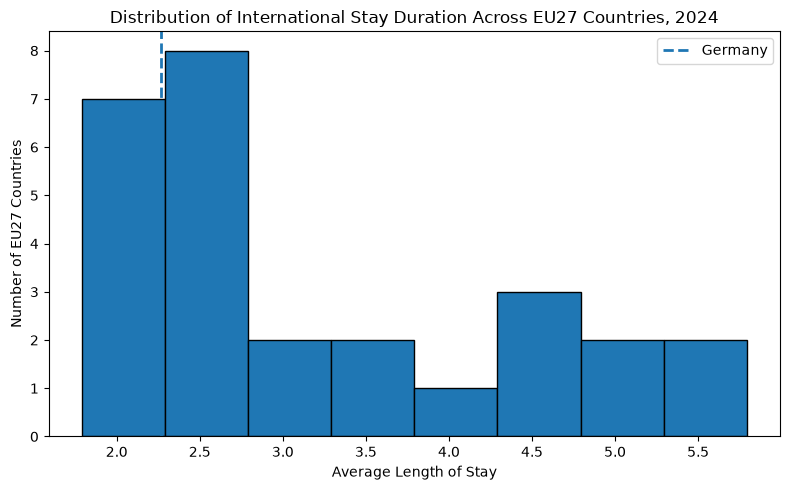

In [72]:
plt.figure(figsize=(8, 5))

plt.hist(
    eu27_2024[
        "avg_length_of_stay"
    ],
    bins=8,
    edgecolor="black"
)

plt.axvline(
    germany_stay,
    linestyle="--",
    linewidth=2,
    label="Germany"
)

plt.xlabel("Average Length of Stay")
plt.ylabel("Number of EU27 Countries")
plt.title(
    "Distribution of International Stay Duration "
    "Across EU27 Countries, 2024"
)

plt.legend()
plt.tight_layout()

plt.show()

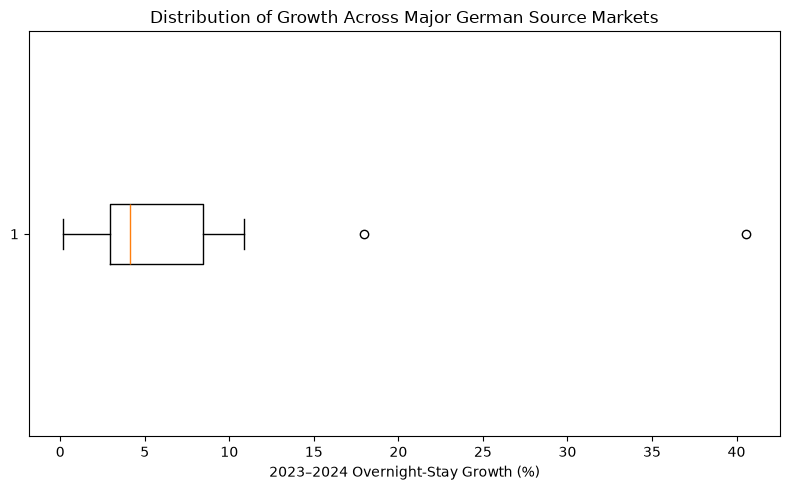

In [76]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    source_opportunity[
        "nights_growth_2024_pct"
    ],
    orientation="horizontal"
)

plt.xlabel(
    "2023–2024 Overnight-Stay Growth (%)"
)

plt.title(
    "Distribution of Growth Across "
    "Major German Source Markets"
)

plt.tight_layout()
plt.show()

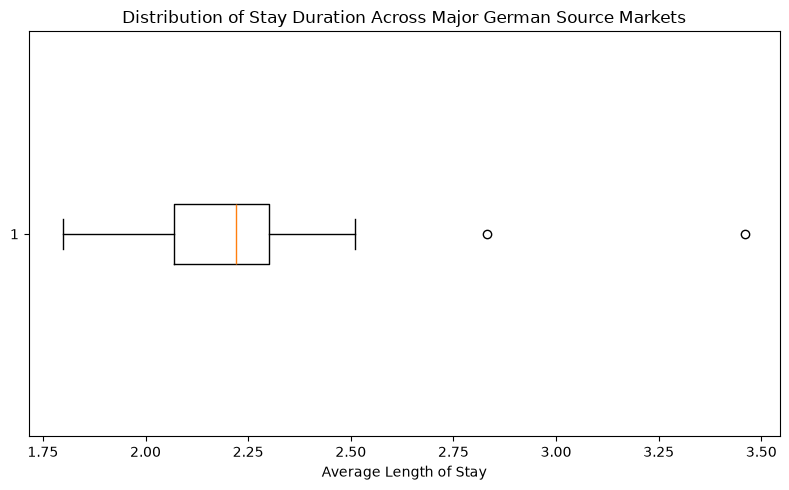

In [77]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    source_opportunity[
        "avg_length_of_stay"
    ],
    orientation="horizontal"
)

plt.xlabel(
    "Average Length of Stay"
)

plt.title(
    "Distribution of Stay Duration Across "
    "Major German Source Markets"
)

plt.tight_layout()
plt.show()

In [75]:
eda_anomalies = pd.DataFrame({
    "observation": [
        "Incomplete historical EU27 country-years",
        "Germany low EU27 stay-duration position",
        "Declining Germany stay duration",
        "High-growth source-market observations",
        "2025 Germany tourism contraction",
        "2025 Balance of Payments observations"
    ],
    "treatment": [
        "Exclude incomplete country-years from full-year comparisons",
        "Retain as genuine competitive characteristic",
        "Retain and investigate statistically",
        "Retain and assess influence on statistical relationships",
        "Retain as genuine annual observation",
        "Retain and label as provisional"
    ]
})

eda_anomalies

,observation,treatment
0,Incomplete historical EU27 country-years,Exclude incomplete country-years from full-yea...
1,Germany low EU27 stay-duration position,Retain as genuine competitive characteristic
2,Declining Germany stay duration,Retain and investigate statistically
3,High-growth source-market observations,Retain and assess influence on statistical rel...
4,2025 Germany tourism contraction,Retain as genuine annual observation
5,2025 Balance of Payments observations,Retain and label as provisional


### Distribution and Outlier Findings

The exploratory outlier analysis identified different patterns across the main analytical dimensions.

For the 2024 EU27 average length-of-stay distribution, the interquartile range was approximately 1.97 nights, with an upper IQR threshold of 7.22 nights and no statistical outliers under the 1.5 × IQR rule.

This indicates that the substantial cross-country differences in average stay duration represent genuine variation in national tourism structures rather than a small number of extreme observations.

Germany's relatively short average stay should therefore be interpreted as a genuine competitive characteristic rather than as a result distorted by extreme EU observations.

Among major German source markets, the 2023–2024 overnight-stay growth distribution contained two high-growth outliers. China recorded growth of approximately 40.55%, while Türkiye recorded growth of approximately 17.95%, both exceeding the upper IQR threshold of approximately 16.69%.

These observations are retained because they represent valid market developments, but their potential influence should be considered when evaluating correlations or other statistical relationships.

The source-market stay-duration distribution also contained two high-value observations. Romania recorded an average stay of approximately 3.46 nights and Poland approximately 2.83 nights, both exceeding the upper IQR threshold of approximately 2.65 nights.

These longer-staying markets are analytically relevant and should not be removed automatically. They represent potentially meaningful differences in source-market travel behavior.

## Exploratory Data Analysis Conclusions

The exploratory analysis identifies several important patterns in Germany's international tourism competitiveness.

### Germany Tourism Performance

Germany experienced a strong international tourism recovery between 2021 and 2024, followed by a modest contraction in 2025.

International arrivals recovered faster than overnight stays throughout most of the period. At the same time, average international length of stay declined from approximately 2.64 nights in 2021 to 2.24 nights in 2025.

The decline in stay duration occurred across all twelve calendar months, indicating that it is not driven by a single season or isolated monthly anomaly.

### EU Competitive Position

Germany holds a strong position in international visitor acquisition but a weaker position in overnight-stay depth.

In the most comparable full EU27 benchmark year, 2024, Germany ranked 4th in international arrivals and 7th in international overnight stays.

Germany's average international stay was approximately 2.27 nights, ranking 21st among the 27 EU countries.

Germany was also slightly below the first quartile of the EU27 stay-duration distribution.

The EU27 visitor-weighted average stay was approximately 3.34 nights, more than one night longer than Germany's average.

### Source-Market Structure

Germany's international tourism demand is moderately concentrated.

The five largest published source markets accounted for approximately 47% of analyzed international overnight stays, while the ten largest accounted for approximately 71%.

The Netherlands represents Germany's largest source market by overnight stays, while the United States, Switzerland and Liechtenstein, Poland, and the United Kingdom also contribute substantial demand.

The United States and United Kingdom combine relatively high market scale, recent growth, and stay duration within the exploratory major-market segmentation.

China recorded exceptionally strong recent growth, while Poland and Romania stand out for comparatively long stays.

Weak descriptive correlations between source-market size, growth, and stay duration indicate that these dimensions capture different aspects of tourism market performance.

### Economic Performance

Germany's international travel receipts increased substantially during the tourism recovery period.

However, outbound international travel expenditure remained considerably higher than inbound travel receipts.

Germany therefore maintained a substantial negative international travel balance throughout the analyzed period.

The provisional 2025 results indicate renewed deterioration in the travel balance as outbound travel expenditure grew faster than inbound travel receipts.

EU27 markets remain the dominant geographic source of international travel receipts. Although Extra-EU27 markets gained relative importance during the earlier recovery period, the data do not show a sustained shift toward Extra-EU receipt dominance.

### Data Quality and Analytical Considerations

Incomplete historical EU27 country-years were excluded from full-year comparisons when necessary.

Official missing observations were preserved rather than imputed.

High-growth and long-stay observations were retained because they represent genuine market behavior rather than confirmed data errors.

Provisional Balance of Payments observations for 2025 were retained and clearly identified.

The exploratory results provide sufficient evidence to proceed to formal statistical analysis.